<a href="https://colab.research.google.com/github/suryasridhar/regime-detection-and-optimization/blob/feature%2Fhmm/ETF_HMM_Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA
from scipy.optimize import minimize


In [2]:
start_date = '2002-09-01' 
end_date = '2025-12-01'
# We put ALL candidates in one big basket. 
# We don't tell the model which is "Growth" or "Defensive".

candidate_tickers = [
    'SPY',           # S&P 500 (Market)
    'QQQ',           # Nasdaq 100 (Growth)
    'XLK',           # Tech Sector (Growth)
    'XLE',           # Energy Sector (Inflation/Value)
    'XLV',           # Healthcare (Defensive)
    'XLP',           # Staples (Defensive)
    'TLT',           # 20+ Year Treasury (The Crisis Hedge) - Launched July 2002
    'IEF',           # 7-10 Year Treasury (Intermediate Safety) - Launched July 2002
    'LQD',           # Investment Grade Corp Bond (Credit Risk) - Launched July 2002
    'NEM',           # Gold Proxy (Newmont Mining) - Used because GLD didn't exist until 2004
]

In [3]:
universe_ohlcv = yf.download(candidate_tickers, start=start_date, end=end_date, group_by='column', auto_adjust=False)
universe_ohlcv = universe_ohlcv.dropna()

[*********************100%***********************]  10 of 10 completed


In [4]:
universe_ohlcv

Price       Adj Close                                                 \
Ticker            IEF         LQD        NEM         QQQ         SPY   
Date                                                                   
2002-09-03  42.276352   38.439087  19.297253   19.077244   56.974751   
2002-09-04  42.261478   38.580986  18.719727   19.153103   57.787918   
2002-09-05  42.430157   38.690117  19.396824   18.681219   57.297451   
2002-09-06  42.102695   38.428158  19.283968   19.254221   58.084831   
2002-09-09  42.043236   38.453590  19.702181   19.448021   58.510792   
...               ...         ...        ...         ...         ...   
2025-11-21  94.732239  107.633560  82.886375  587.922485  653.614929   
2025-11-24  94.878433  108.060532  85.904404  602.957581  663.235107   
2025-11-25  95.122108  108.361336  85.646278  606.674072  669.473511   
2025-11-26  95.200089  108.730087  90.126732  612.034424  674.095215   
2025-11-28  95.034386  108.545715  90.335823  616.996277  677.774719   

Price                                                                ...  \
Ticker            TLT        XLE         XLK        XLP         XLV  ...   
Date                                                                 ...   
2002-09-03  38.868313   5.709551    5.016902  11.477679   17.535419  ...   
2002-09-04  38.859493   5.696575    5.172984  11.570589   18.074762  ...   
2002-09-05  39.071407   5.706954    4.998321  11.565131   17.865765  ...   
2002-09-06  38.612263   5.800383    5.165551  11.565131   17.865765  ...   
2002-09-09  38.554874   5.792599    5.221296  11.794681   18.068026  ...   
...               ...        ...         ...        ...         ...  ...   
2025-11-21  86.866013  43.728958  136.061523  76.317909  152.650848  ...   
2025-11-24  87.361000  43.606705  139.303665  75.436188  153.292633  ...   
2025-11-25  87.584221  43.332848  139.677200  76.474663  156.758148  ...   
2025-11-26  87.972458  43.660496  141.330658  77.307396  156.412582  ...   
2025-11-28  87.555107  44.232658  142.545837  77.758064  155.652328  ...   

Price         Volume                                                      \
Ticker           IEF       LQD       NEM        QQQ        SPY       TLT   
Date                                                                       
2002-09-03    110700     49300   4460700   81828100   76586400    102100   
2002-09-04     77300   1690000   4369300   82717600   51099500     66300   
2002-09-05     57900    138300   5563300   91576600   67250900    648400   
2002-09-06     32200    224800   5734100   86008800   38622200    140000   
2002-09-09     88800     53600   6889700   72679500   33998400     83800   
...              ...       ...       ...        ...        ...       ...   
2025-11-21  12551100  41000500  10168500  103344200  123956200  41938600   
2025-11-24   6903900  28437900  16768900   60168100   80437900  30865700   
2025-11-25   9193400  47560900   8176100   57560900   81077100  36503300   
2025-11-26   7747100  24585400   7259100   42393600   71879600  34099000   
2025-11-28   7798000  25471200   4824600   23034400   49212000  40704300   

Price                                               
Ticker           XLE       XLK       XLP       XLV  
Date                                                
2002-09-03    177800   2919800     75000     55000  
2002-09-04   1249000   1838400     51700     87400  
2002-09-05    516600    785800     33500     31900  
2002-09-06    421000   5887800     65400     17700  
2002-09-09    206600   1398400     37500     29300  
...              ...       ...       ...       ...  
2025-11-21  39317200  44959000  22216000  25526100  
2025-11-24  33681800  20124800  17869400  17928400  
2025-11-25  29299000  21303400  18586300  17298600  
2025-11-26  26611000  13358800  13275100  12398900  
2025-11-28  16666600   6792200   8914300   8559700  

[5849 rows x 60 columns]

In [5]:
vix = yf.download('^VIX', start=start_date, end=end_date, progress=False, auto_adjust=False, multi_level_index=False)['Adj Close']
vix

Date
2002-09-03    39.970001
2002-09-04    37.439999
2002-09-05    38.860001
2002-09-06    36.330002
2002-09-09    36.450001
                ...    
2025-11-21    23.430000
2025-11-24    20.520000
2025-11-25    18.559999
2025-11-26    17.190001
2025-11-28    16.350000
Name: Adj Close, Length: 5849, dtype: float64

In [6]:
adj_close = universe_ohlcv['Adj Close']
high = universe_ohlcv['High']
low = universe_ohlcv['Low']
close = universe_ohlcv['Close']
open_p = universe_ohlcv['Open']
volume = universe_ohlcv['Volume']

In [7]:
def calculate_yang_zhang_vol(open_df, high_df, low_df, close_df, window=14):
    """
    Vectorized Yang-Zhang Volatility.
    Captures Overnight Risk + Open-to-Close Risk efficiently.
    """
    # 1. Overnight Volatility (Close to Open)
    # Shift Close to get previous day's close
    log_oc = np.log(open_df / close_df.shift(1))
    # Rolling Variance of overnight jumps
    vo = log_oc.rolling(window=window).var()
    
    # 2. Open-to-Close Volatility
    log_co = np.log(close_df / open_df)
    vc = log_co.rolling(window=window).var()
    
    # 3. Rogers-Satchell Volatility (Intraday Trend-Agnostic)
    # RS = mean( log(H/C)*log(H/O) + log(L/C)*log(L/O) )
    log_hc = np.log(high_df / close_df)
    log_ho = np.log(high_df / open_df)
    log_lc = np.log(low_df / close_df)
    log_lo = np.log(low_df / open_df)
    
    rs_term = (log_hc * log_ho) + (log_lc * log_lo)
    vrs = rs_term.rolling(window=window).mean()
    
    # 4. Combine (Standard weights for YZ)
    k = 0.34 / (1.34 + (window + 1) / (window - 1))
    
    # Yang-Zhang Variance
    yz_var = vo + k * vc + (1 - k) * vrs
    
    # Annualize
    return np.sqrt(yz_var) * np.sqrt(252)

In [8]:
print("Calculating Yang-Zhang Volatility (Overnight Gap Aware)...")
# We use YZ Volatility as our primary "Risk" input now
feat_vol = calculate_yang_zhang_vol(open_p, high, low, close, window=14)

Calculating Yang-Zhang Volatility (Overnight Gap Aware)...


In [9]:
print("Calculating Rolling Skewness & Kurtosis (Tail Risk)...")
returns = adj_close.pct_change()

# Rolling Skew (63-day / Quarterly window is standard to reduce noise)
# Negative Skew = "Crash Risk" (Small wins, big losses)
feat_skew = returns.rolling(window=63).skew()

# Rolling Kurtosis (Fat Tails)
# High Kurtosis = "Fragile Market" (Frequent 3-sigma events)
feat_kurt = returns.rolling(window=63).kurt()

Calculating Rolling Skewness & Kurtosis (Tail Risk)...


In [10]:
# --- RSI (14-Day) ---
delta = adj_close.diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
feat_rsi = 100 - (100 / (1 + rs))

In [11]:
print("Calculating Momentum (14-Day Returns)...")
feat_mom = adj_close.pct_change(14)

Calculating Momentum (14-Day Returns)...


In [12]:
typical_price = (high + low + close) / 3
money_flow = typical_price * volume
tp_diff = typical_price.diff()
pos_flow = (money_flow * (tp_diff > 0).astype(int)).rolling(14).sum()
neg_flow = (money_flow * (tp_diff < 0).astype(int)).rolling(14).sum()
mfi_ratio = pos_flow / neg_flow
feat_mfi = 100 - (100 / (1 + mfi_ratio))

In [13]:
features = pd.DataFrame(index=adj_close.index)

In [14]:
print("Constructing High-Dimensional Feature Matrix...")
df = pd.concat([
    feat_vol.add_suffix('_YZ_Vol'),
    feat_skew.add_suffix('_Skew'),
    feat_kurt.add_suffix('_Kurt'),
    feat_mom.add_suffix('_Mom'), # Added Momentum
    feat_rsi.add_suffix('_RSI'),
    feat_mfi.add_suffix('_MFI')
], axis=1)


Constructing High-Dimensional Feature Matrix...


In [15]:
df = df.dropna()
df

Ticker,IEF_YZ_Vol,LQD_YZ_Vol,NEM_YZ_Vol,QQQ_YZ_Vol,SPY_YZ_Vol,TLT_YZ_Vol,XLE_YZ_Vol,XLK_YZ_Vol,XLP_YZ_Vol,XLV_YZ_Vol,...,IEF_MFI,LQD_MFI,NEM_MFI,QQQ_MFI,SPY_MFI,TLT_MFI,XLE_MFI,XLK_MFI,XLP_MFI,XLV_MFI
Date,,,,,,,,,,,,,,,,,,,,,
2002-12-02,0.090562,0.088241,0.462555,0.376274,0.214882,0.127344,0.202728,0.377478,0.190291,0.185377,...,9.380073,25.080414,28.821286,82.012675,68.463985,16.273236,70.814399,86.995138,39.831979,17.993979
2002-12-03,0.092859,0.088162,0.413424,0.374356,0.215447,0.130117,0.203723,0.381091,0.175246,0.196602,...,11.812610,60.029953,41.105145,74.969410,61.919616,22.936932,75.627698,74.930493,47.191419,17.347102
2002-12-04,0.096094,0.084618,0.408400,0.372651,0.214126,0.132263,0.183831,0.397385,0.172764,0.184409,...,23.172738,53.472613,51.018603,63.966404,61.617434,27.549589,70.778042,67.466749,47.196955,21.232398
2002-12-05,0.093195,0.079016,0.397293,0.368434,0.210130,0.129101,0.179360,0.390043,0.165157,0.181553,...,34.095933,56.269823,53.043344,56.598229,55.292629,34.123029,65.894177,62.404187,40.091737,21.962561
2002-12-06,0.100664,0.086764,0.442213,0.378538,0.218570,0.140493,0.187939,0.394006,0.167109,0.190618,...,42.621596,58.053839,57.533776,50.073981,47.287760,44.744745,70.564992,58.216100,40.700488,19.709592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-21,0.041082,0.045234,0.475634,0.253188,0.186275,0.076793,0.225085,0.313322,0.115842,0.143848,...,40.732900,57.734246,42.907718,22.641934,27.927224,41.245952,56.034168,16.281587,54.664903,76.182656
2025-11-24,0.041327,0.043404,0.453587,0.249978,0.182793,0.078421,0.225680,0.307098,0.116279,0.144758,...,41.027728,54.842873,52.568825,28.731774,33.957702,41.857323,55.486726,21.499878,46.927342,76.643700
2025-11-25,0.039610,0.044276,0.451095,0.254501,0.186340,0.073425,0.225372,0.316848,0.114777,0.144302,...,47.251833,63.864217,52.567153,29.261332,34.259112,51.244380,50.122780,21.165291,54.281741,77.137375


In [16]:
print("Applying Rolling Normalization (252-Day Window)...")

rolling_mean = df.rolling(window=252).mean()
rolling_std = df.rolling(window=252).std()
epsilon = 1e-8

normalized_df = (df - rolling_mean) / (rolling_std + epsilon)
normalized_df = normalized_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Applying 21-Day EMA Smoothing to Features (Anti-Chop)...")
normalized_df = normalized_df.ewm(span=21).mean()

print(f"Normalized & Smoothed Matrix Shape: {normalized_df.shape}")

Applying Rolling Normalization (252-Day Window)...
Applying 21-Day EMA Smoothing to Features (Anti-Chop)...
Normalized & Smoothed Matrix Shape: (5535, 60)


In [17]:
X_values = normalized_df.values
dates = normalized_df.index
returns_universe = np.log(adj_close / adj_close.shift(1)).reindex(dates)



In [18]:
dates

DatetimeIndex(['2003-12-01', '2003-12-02', '2003-12-03', '2003-12-04',
               '2003-12-05', '2003-12-08', '2003-12-09', '2003-12-10',
               '2003-12-11', '2003-12-12',
               ...
               '2025-11-14', '2025-11-17', '2025-11-18', '2025-11-19',
               '2025-11-20', '2025-11-21', '2025-11-24', '2025-11-25',
               '2025-11-26', '2025-11-28'],
              dtype='datetime64[ns]', name='Date', length=5535, freq=None)

In [19]:
# THE CUT-OFF POINT
# We use the first ~4 years (2006-2010) as "Burn-In" to initialize the model.
# We do NOT trade during this period.
initial_train_window = 1000
rebalance_step = 63 

# Print the Hard Line in the Sand
burn_in_end_date = dates[initial_train_window]
burn_in_end_date

Timestamp('2007-11-20 00:00:00')

In [20]:
print(f"1. In-Sample 'Burn-In' Period: {dates[0].date()} to {burn_in_end_date.date()}")

1. In-Sample 'Burn-In' Period: 2003-12-01 to 2007-11-20


In [21]:
def get_optimized_weights(returns_df, objective='sharpe', rf=0.0):

    num_assets = len(returns_df.columns)
    if num_assets == 0:
        return []
    if num_assets == 1:
        return np.array([1.0])

    # Annualized moments
    mean_rets = returns_df.mean() * 252
    cov_matrix = returns_df.cov() * 252

    # Constraints: fully invested, long-only
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array([1 / num_assets] * num_assets)

    def min_variance_func(weights):
        return np.dot(weights, np.dot(cov_matrix, weights.T))

    def sharpe_func(weights):
        port_ret = np.dot(mean_rets, weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return port_ret / port_vol if port_vol > 0 else 0.0

    def sortino_func(weights):
        # Portfolio daily returns
        port_rets = returns_df.values @ weights

        # Downside deviation (annualized)
        downside_rets = np.minimum(port_rets - rf / 252, 0)
        downside_vol = np.sqrt(np.mean(downside_rets**2)) * np.sqrt(252)

        port_ret = np.dot(mean_rets, weights) - rf

        return port_ret / downside_vol if downside_vol > 0 else 0.0


    if objective == 'min_var':
        result = minimize(
            min_variance_func,
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    elif objective == 'sortino':
        result = minimize(
            lambda w: -sortino_func(w),
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    else:  # sharpe
        result = minimize(
            lambda w: -sharpe_func(w),
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    return result.x

In [22]:
# =============================
# SETUP
# =============================
vol_cols = [i for i, col in enumerate(normalized_df.columns) if '_YZ_Vol' in col]

initial_train_window = 1000
rebalance_step = 63

portfolio_log_returns = []
benchmark_log_returns = []
regime_history = []
portfolio_dates = []

n_pca_components = 4
n_hmm_states = 2

pca = PCA(n_components=n_pca_components)

SWITCH_THRESHOLD = 0.9
current_regime = 0  # 0 = Low Vol (Green), 1 = High Vol (Red)

print(f"--- Starting Walk-Forward Loop (Hysteresis={SWITCH_THRESHOLD}) ---")

# =============================
# WALK-FORWARD LOOP
# =============================
for t in range(initial_train_window, len(X_values) - rebalance_step, rebalance_step):

    # =============================
    # 1. TRAIN PCA + HMM (PAST ONLY)
    # =============================
    X_train = X_values[:t]
    train_returns = returns_universe.iloc[:t]

    X_train_pca = pca.fit_transform(X_train)

    hmm = GaussianHMM(
        n_components=n_hmm_states,
        covariance_type="full",
        n_iter=100,
        random_state=42
    )
    hmm.fit(X_train_pca)

    train_states_raw = hmm.predict(X_train_pca)

    # =============================
    # 2. STATE ALIGNMENT (LOW VOL = 0)
    # =============================
    state_vols = [
        X_train[train_states_raw == s][:, vol_cols].mean()
        for s in range(n_hmm_states)
    ]

    map_dict = {
        old_id: new_id
        for new_id, old_id in enumerate(np.argsort(state_vols))
    }

    train_states = np.array([map_dict[s] for s in train_states_raw])

    # =============================
    # 3. BUILD STATE PLAYBOOK (TRAINING ONLY)
    # =============================
    state_playbook = {}

    for state in range(n_hmm_states):

        mask = (train_states == state)

        if mask.sum() < 20:
            state_playbook[state] = {'SPY': 1.0}
            continue

        regime_returns = train_returns[mask]

        # ---------- STATE 0: TAIL HARVESTING ----------
        if state == 0:

            market_strength = regime_returns.mean(axis=1)
            strong_days = market_strength > market_strength.quantile(0.60)
            filtered = regime_returns.loc[strong_days]

            if len(filtered) < 15:
                state_playbook[state] = {'SPY': 1.0}
                continue

            right_tail = filtered.quantile(0.90)
            left_tail = filtered.quantile(0.10).abs()
            skew = filtered.skew()

            tail_ratio = right_tail / (left_tail + 1e-6)

            tail_score = (
                0.5 * tail_ratio.rank(pct=True) +
                0.3 * right_tail.rank(pct=True) +
                0.2 * skew.rank(pct=True)
            )

            selected_assets = tail_score.nlargest(3).index.tolist()

            raw_weights = tail_score[selected_assets]
            weights = raw_weights ** 1.5
            weights = weights / weights.sum()

            state_playbook[state] = dict(zip(selected_assets, weights))

        # ---------- STATE 1: DEFENSIVE ----------
        else:
            avg_rets = regime_returns.mean()
            valid_assets = avg_rets[avg_rets > 0].index.tolist()

            if len(valid_assets) == 0:
                state_playbook[state] = {'IEF': 1.0}
            else:
                w = 1.0 / len(valid_assets)
                state_playbook[state] = {a: w for a in valid_assets}

    # =============================
    # 4. DAY-BY-DAY REGIME INFERENCE + EXECUTION
    # =============================
    end_idx = min(t + rebalance_step, len(X_values))
    X_test = X_values[t:end_idx]
    test_returns_slice = returns_universe.iloc[t:end_idx]

    X_test_pca = pca.transform(X_test)

    for i in range(len(X_test_pca) - 1):

        # Online regime inference
        X_so_far = np.vstack([X_train_pca, X_test_pca[:i+1]])
        probs = hmm.predict_proba(X_so_far)[-1]

        aligned_probs = np.zeros(n_hmm_states)
        for old_id, new_id in map_dict.items():
            aligned_probs[new_id] = probs[old_id]

        # Hysteresis
        prob_red = aligned_probs[1]
        if current_regime == 0 and prob_red > SWITCH_THRESHOLD:
            current_regime = 1
        elif current_regime == 1 and prob_red < (1 - SWITCH_THRESHOLD):
            current_regime = 0

        regime_history.append(current_regime)

        # ---------- EXECUTE NEXT DAY ----------
        next_day_returns = test_returns_slice.iloc[i + 1]
        weights = state_playbook[current_regime]

        daily_ret = sum(next_day_returns[tkr] * w for tkr, w in weights.items())

        if current_regime == 0:
            prob_green = aligned_probs[0]
            daily_ret *= 1.5 * (0.5 + prob_green)

        portfolio_log_returns.append(daily_ret)
        benchmark_log_returns.append(next_day_returns['SPY'])
        portfolio_dates.append(next_day_returns.name)

    if t % (rebalance_step * 4) == 0:
        print(f"Processed up to: {returns_universe.index[t].date()}")

# =============================
# RESULTS DATAFRAME
# =============================
results = pd.DataFrame(
    {
        'Strategy': np.exp(np.cumsum(portfolio_log_returns)),
        'Benchmark': np.exp(np.cumsum(benchmark_log_returns)),
        'Regime': regime_history
    },
    index=pd.DatetimeIndex(portfolio_dates)
)

--- Starting Walk-Forward Loop (Hysteresis=0.9) ---


In [23]:
results

,Strategy,Benchmark,Regime
2007-11-21,0.990295,0.979536,1
2007-11-23,0.999674,0.996474,1
2007-11-26,0.992545,0.974488,1
2007-11-27,0.995528,0.985689,1
2007-11-28,1.010761,1.017215,1
...,...,...,...
2025-08-26,61.082916,7.219189,0
2025-08-27,61.493819,7.235639,0
2025-08-28,62.294107,7.261263,0
2025-08-29,60.807586,7.217959,0


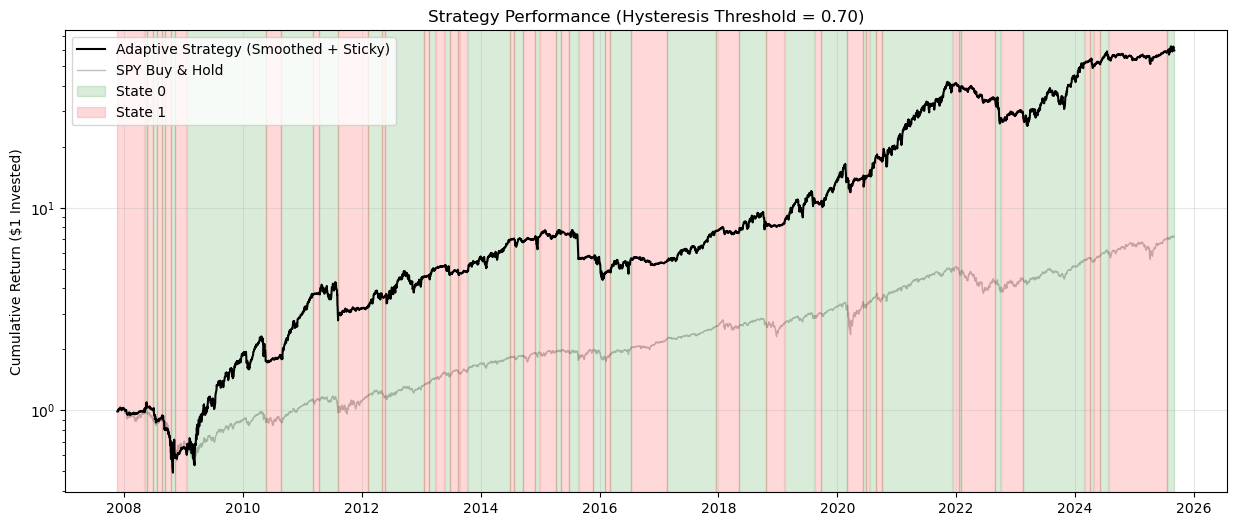

In [24]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(results['Strategy'], label='Adaptive Strategy (Smoothed + Sticky)', color='black', linewidth=1.5, zorder=2)
ax.plot(results['Benchmark'], label='SPY Buy & Hold', color='gray', alpha=0.5, linewidth=1, zorder=1)

state_colors = {0: 'green', 1: 'red'}
y_min, y_max = ax.get_ylim()
for state in range(n_hmm_states):
    mask = (results['Regime'] == state)
    ax.fill_between(results.index, 0, 100000, where=mask, 
                    color=state_colors.get(state, 'blue'), alpha=0.15, 
                    transform=ax.get_xaxis_transform(), label=f'State {state}')

ax.set_yscale('log')
ax.set_title("Strategy Performance (Hysteresis Threshold = 0.70)")
ax.set_ylabel("Cumulative Return ($1 Invested)")
ax.set_ylim(results['Strategy'].min() * 0.8, results['Strategy'].max() * 1.2)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

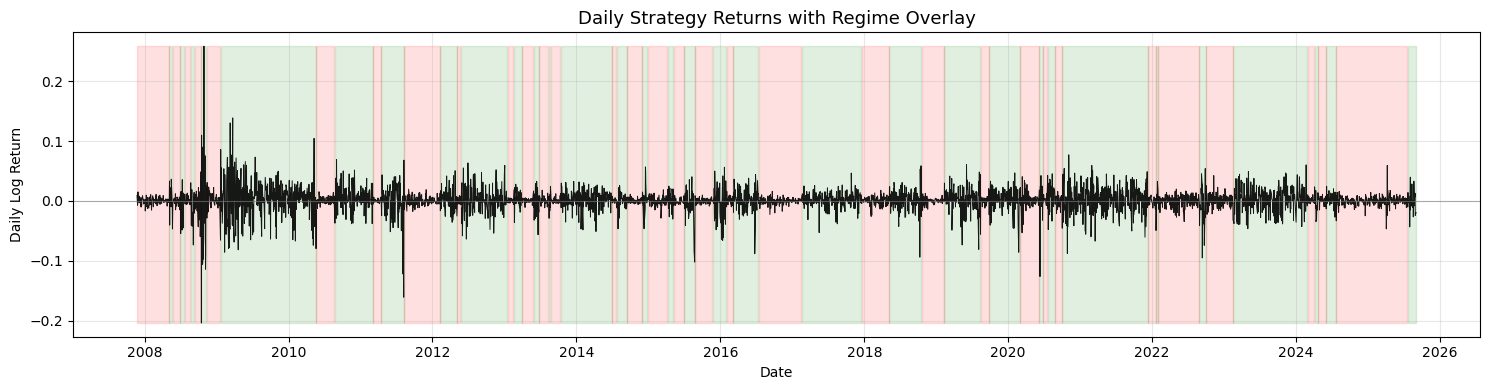

In [25]:
# Recover daily log returns from cumulative series
strategy_daily_returns = np.diff(np.log(results['Strategy']))
dates_daily = results.index[1:]

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(
    dates_daily,
    strategy_daily_returns,
    color='black',
    linewidth=0.7,
    alpha=0.9,
    label='Daily Log Returns'
)

# Regime shading (shifted by 1 due to diff)
for state in np.unique(results['Regime'].values[1:]):
    mask = results['Regime'].values[1:] == state
    ax.fill_between(
        dates_daily,
        strategy_daily_returns.min(),
        strategy_daily_returns.max(),
        where=mask,
        color=state_colors.get(state, 'blue'),
        alpha=0.12
    )

# Formatting
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax.set_title("Daily Strategy Returns with Regime Overlay", fontsize=13)
ax.set_ylabel("Daily Log Return")
ax.set_xlabel("Date")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

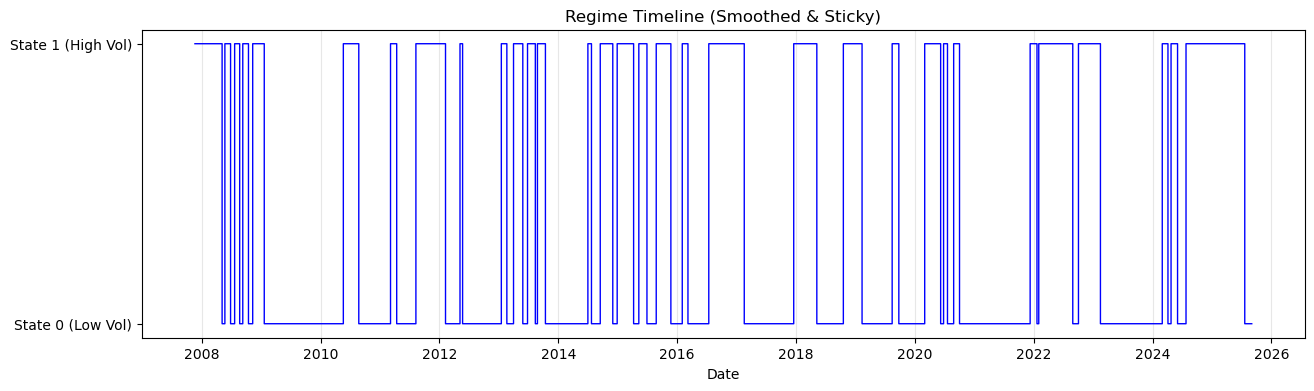

In [26]:
# PLOT 2: REGIME TIMELINE (DE-BARCODED)
plt.figure(figsize=(15, 4))
plt.plot(results.index, results['Regime'], drawstyle='steps-post', color='blue', linewidth=1)
plt.yticks([0, 1], ['State 0 (Low Vol)', 'State 1 (High Vol)'])
plt.title("Regime Timeline (Smoothed & Sticky)")
plt.xlabel("Date")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [27]:
TRADING_DAYS = 252

# =============================
# DAILY LOG RETURNS
# =============================
strategy_rets = np.diff(np.log(results['Strategy'].values))
benchmark_rets = np.diff(np.log(results['Benchmark'].values))

# Align dates
rets_df = pd.DataFrame({
    "Strategy": strategy_rets,
    "Benchmark": benchmark_rets
}, index=results.index[1:])


# =============================
# SORTINO RATIO
# =============================
def sortino_ratio(returns, periods=252):
    downside = returns[returns < 0]
    if len(downside) == 0:
        return np.nan
    return np.sqrt(periods) * returns.mean() / downside.std(ddof=1)


strategy_sortino = sortino_ratio(rets_df["Strategy"].values)
benchmark_sortino = sortino_ratio(rets_df["Benchmark"].values)


# =============================
# MAX DRAWDOWN
# =============================
def max_drawdown_from_equity(equity_curve):
    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = equity_curve / running_max - 1.0
    return drawdowns.min()


strategy_max_dd = max_drawdown_from_equity(results["Strategy"].values)
benchmark_max_dd = max_drawdown_from_equity(results["Benchmark"].values)


# =============================
# OUTPUT
# =============================
summary = pd.DataFrame({
    "Metric": ["Sortino Ratio", "Max Drawdown"],
    "Strategy": [strategy_sortino, strategy_max_dd],
    "Benchmark": [benchmark_sortino, benchmark_max_dd]
})

print(summary)

          Metric  Strategy  Benchmark
0  Sortino Ratio  0.900046   0.680044
1   Max Drawdown -0.550089  -0.493156


In [28]:
# =============================
# METRICS FROM 2009 ONWARD
# =============================

TRADING_DAYS = 252
START_DATE = "2009-01-01"

# -----------------------------
# FILTER RESULTS
# -----------------------------
results_2009 = results.loc[results.index >= START_DATE].copy()

# -----------------------------
# DAILY LOG RETURNS
# -----------------------------
strategy_rets = np.diff(np.log(results_2009["Strategy"].values))
benchmark_rets = np.diff(np.log(results_2009["Benchmark"].values))

rets_df = pd.DataFrame(
    {
        "Strategy": strategy_rets,
        "Benchmark": benchmark_rets
    },
    index=results_2009.index[1:]
)

strategy_sortino = sortino_ratio(rets_df["Strategy"].values)
benchmark_sortino = sortino_ratio(rets_df["Benchmark"].values)

strategy_max_dd = max_drawdown_from_equity(results_2009["Strategy"].values)
benchmark_max_dd = max_drawdown_from_equity(results_2009["Benchmark"].values)

# -----------------------------
# SUMMARY TABLE
# -----------------------------
summary = pd.DataFrame({
    "Metric": ["Sortino Ratio (2009+)", "Max Drawdown (2009+)"],
    "Strategy": [strategy_sortino, strategy_max_dd],
    "Benchmark": [benchmark_sortino, benchmark_max_dd]
})

print(summary)

                  Metric  Strategy  Benchmark
0  Sortino Ratio (2009+)  1.138223   0.957755
1   Max Drawdown (2009+) -0.433281  -0.306004


In [29]:
# ============================================================
# Comprehensive Performance Metrics
# ============================================================

TRADING_DAYS = 252
RF = 0.0  # risk-free rate

def compute_metrics(equity_curve, label, rf=0.0, periods=252):
    rets = np.diff(np.log(equity_curve))

    # CAGR
    n_years  = len(rets) / periods
    cagr     = (equity_curve[-1] / equity_curve[0]) ** (1 / n_years) - 1

    # Volatility
    ann_vol  = rets.std() * np.sqrt(periods)

    # Sharpe
    sharpe   = (rets.mean() * periods - rf) / ann_vol if ann_vol > 0 else np.nan

    # Sortino
    downside = rets[rets < 0]
    sortino  = (rets.mean() * periods - rf) / (downside.std(ddof=1) * np.sqrt(periods)) if len(downside) > 0 else np.nan

    # Max Drawdown
    running_max = np.maximum.accumulate(equity_curve)
    drawdowns   = equity_curve / running_max - 1.0
    max_dd      = drawdowns.min()

    # Calmar
    calmar   = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # Beta & Alpha vs benchmark (computed outside, passed in)
    return {
        'Label'           : label,
        'CAGR (%)'        : round(cagr * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Sortino'         : round(sortino, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


def compute_beta_alpha(strategy_rets, benchmark_rets, periods=252):
    cov    = np.cov(strategy_rets, benchmark_rets)
    beta   = cov[0, 1] / cov[1, 1] if cov[1, 1] > 0 else np.nan
    alpha  = (strategy_rets.mean() - beta * benchmark_rets.mean()) * periods
    return round(beta, 4), round(alpha * 100, 2)


def win_rate_quarterly(strategy_rets, benchmark_rets, step=63):
    wins = 0
    total = 0
    for i in range(0, len(strategy_rets) - step, step):
        s = strategy_rets[i:i+step].sum()
        b = benchmark_rets[i:i+step].sum()
        wins  += int(s > b)
        total += 1
    return round(wins / total * 100, 2) if total > 0 else np.nan


def regime_stats(regime_history):
    regimes = np.array(regime_history)
    n_total = len(regimes)
    n_low   = (regimes == 0).sum()
    n_high  = (regimes == 1).sum()
    switches = (np.diff(regimes) != 0).sum()
    return {
        'Days Low Vol (%)' : round(n_low / n_total * 100, 2),
        'Days High Vol (%)': round(n_high / n_total * 100, 2),
        'Regime Switches'  : int(switches),
    }


# ============================================================
# Full Period
# ============================================================

strat_eq  = results['Strategy'].values
bench_eq  = results['Benchmark'].values
strat_rets = np.diff(np.log(strat_eq))
bench_rets = np.diff(np.log(bench_eq))

m_strat = compute_metrics(strat_eq,  'Strategy',  rf=RF)
m_bench = compute_metrics(bench_eq,  'Benchmark', rf=RF)

beta, alpha = compute_beta_alpha(strat_rets, bench_rets)
m_strat['Beta']      = beta
m_strat['Alpha (%)'] = alpha
m_bench['Beta']      = 1.0
m_bench['Alpha (%)'] = 0.0

wr = win_rate_quarterly(strat_rets, bench_rets)
m_strat['Win Rate (%)'] = wr
m_bench['Win Rate (%)'] = '-'

metrics_full = pd.DataFrame([m_strat, m_bench]).set_index('Label')
print("=== Full Period ===")
print(metrics_full.T.to_string())

# ============================================================
# 2009+ Period
# ============================================================

results_2009  = results.loc[results.index >= '2009-01-01']
strat_eq_09   = results_2009['Strategy'].values
bench_eq_09   = results_2009['Benchmark'].values
strat_rets_09 = np.diff(np.log(strat_eq_09))
bench_rets_09 = np.diff(np.log(bench_eq_09))

m_strat_09 = compute_metrics(strat_eq_09,  'Strategy (2009+)',  rf=RF)
m_bench_09 = compute_metrics(bench_eq_09,  'Benchmark (2009+)', rf=RF)

beta_09, alpha_09 = compute_beta_alpha(strat_rets_09, bench_rets_09)
m_strat_09['Beta']      = beta_09
m_strat_09['Alpha (%)'] = alpha_09
m_bench_09['Beta']      = 1.0
m_bench_09['Alpha (%)'] = 0.0

wr_09 = win_rate_quarterly(strat_rets_09, bench_rets_09)
m_strat_09['Win Rate (%)'] = wr_09
m_bench_09['Win Rate (%)'] = '-'

metrics_09 = pd.DataFrame([m_strat_09, m_bench_09]).set_index('Label')
print("\n=== 2009+ Period ===")
print(metrics_09.T.to_string())

# ============================================================
# Regime Statistics
# ============================================================

reg_stats = regime_stats(regime_history)
print("\n=== Regime Statistics ===")
for k, v in reg_stats.items():
    print(f"  {k}: {v}")

=== Full Period ===
Label            Strategy Benchmark
CAGR (%)            26.45     12.07
Ann. Vol (%)        30.65     20.06
Sharpe             0.7656    0.5681
Sortino               0.9      0.68
Max Drawdown (%)   -55.01    -49.32
Calmar             0.4808    0.2447
Beta               1.0891       1.0
Alpha (%)           11.06       0.0
Win Rate (%)        63.77         -

=== 2009+ Period ===
Label            Strategy (2009+) Benchmark (2009+)
CAGR (%)                    31.71             15.25
Ann. Vol (%)                29.08             18.01
Sharpe                     0.9472            0.7883
Sortino                    1.1382            0.9578
Max Drawdown (%)           -43.33             -30.6
Calmar                     0.7318            0.4985
Beta                       1.1645               1.0
Alpha (%)                   11.01               0.0
Win Rate (%)                61.54                 -

=== Regime Statistics ===
  Days Low Vol (%): 58.11
  Days High Vol (%): 41.8

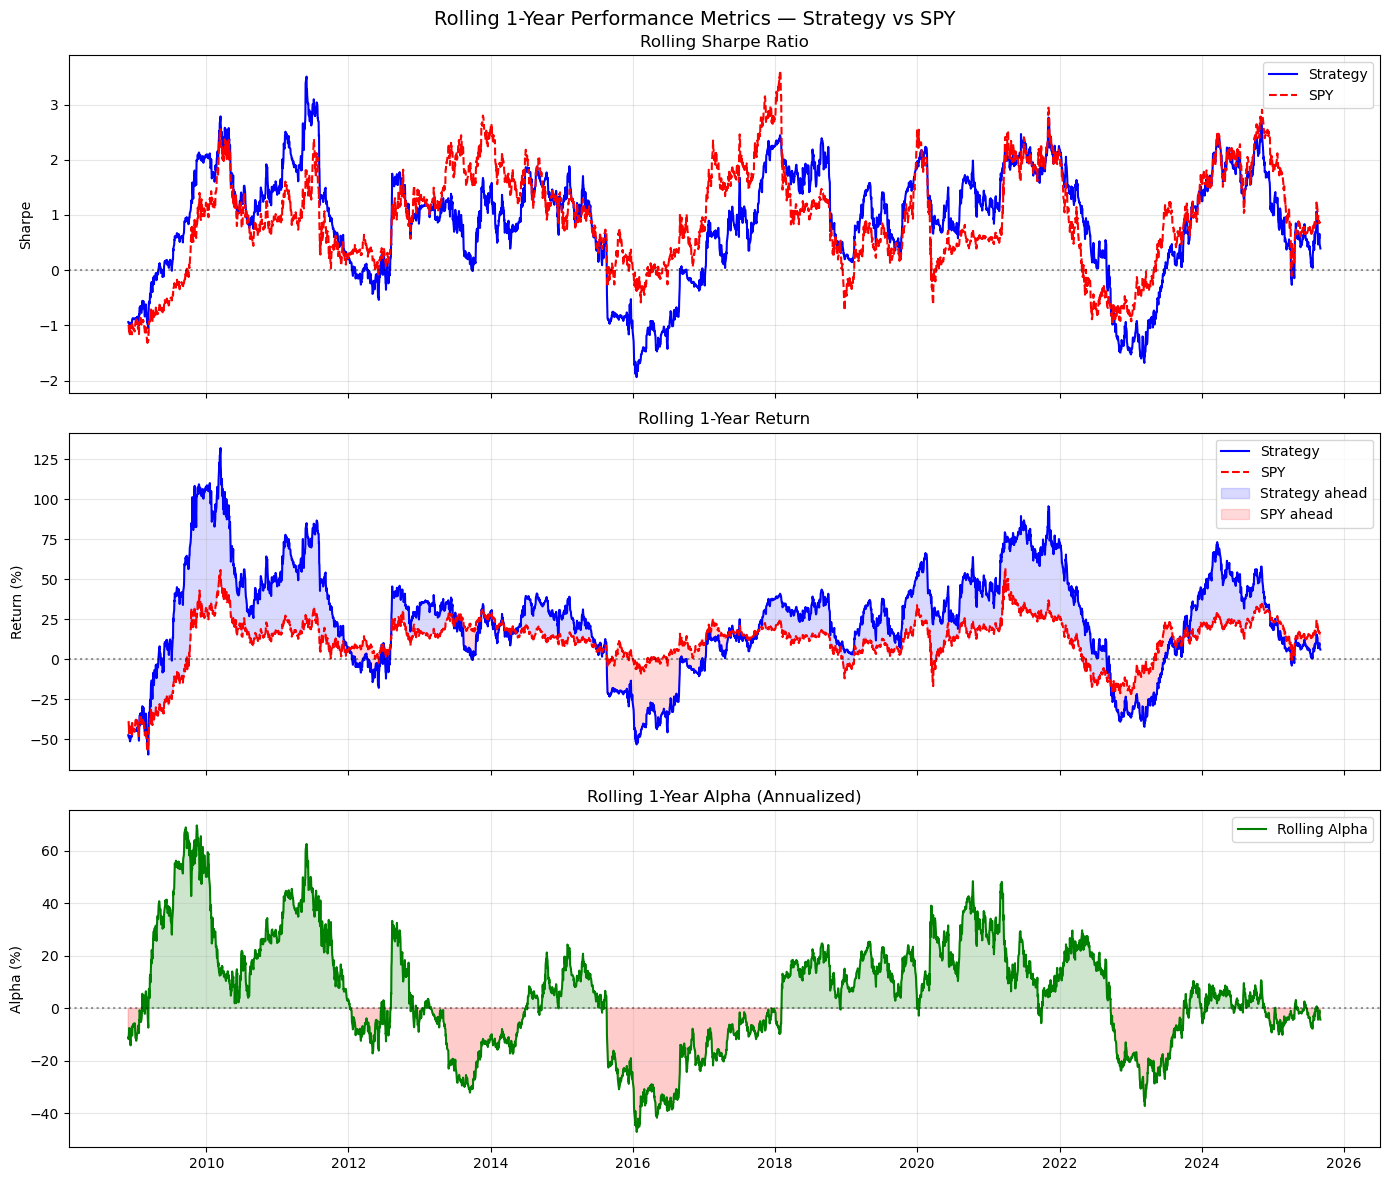

In [30]:
# ============================================================
# Rolling Metrics — 1-Year Window
# ============================================================

import matplotlib.dates as mdates

WINDOW = 252  # 1-year rolling

rets_df = pd.DataFrame({
    'Strategy' : np.diff(np.log(results['Strategy'].values)),
    'Benchmark': np.diff(np.log(results['Benchmark'].values))
}, index=results.index[1:])

# Rolling Sharpe
roll_sharpe_strat = (
    rets_df['Strategy'].rolling(WINDOW).mean() * TRADING_DAYS /
    (rets_df['Strategy'].rolling(WINDOW).std() * np.sqrt(TRADING_DAYS))
)
roll_sharpe_bench = (
    rets_df['Benchmark'].rolling(WINDOW).mean() * TRADING_DAYS /
    (rets_df['Benchmark'].rolling(WINDOW).std() * np.sqrt(TRADING_DAYS))
)

# Rolling Annual Return
roll_ret_strat = rets_df['Strategy'].rolling(WINDOW).sum()
roll_ret_bench = rets_df['Benchmark'].rolling(WINDOW).sum()

# Rolling Alpha (1-year)
roll_cov   = rets_df['Strategy'].rolling(WINDOW).cov(rets_df['Benchmark'])
roll_var   = rets_df['Benchmark'].rolling(WINDOW).var()
roll_beta  = roll_cov / roll_var
roll_alpha = (rets_df['Strategy'].rolling(WINDOW).mean() -
              roll_beta * rets_df['Benchmark'].rolling(WINDOW).mean()) * TRADING_DAYS

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Rolling 1-Year Performance Metrics — Strategy vs SPY', fontsize=14)

# Plot 1 — Rolling Sharpe
axes[0].plot(roll_sharpe_strat.index, roll_sharpe_strat,
             color='blue', linewidth=1.5, label='Strategy')
axes[0].plot(roll_sharpe_bench.index, roll_sharpe_bench,
             color='red', linewidth=1.5, linestyle='--', label='SPY')
axes[0].axhline(0, color='black', linestyle=':', alpha=0.4)
axes[0].set_title('Rolling Sharpe Ratio')
axes[0].set_ylabel('Sharpe')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Rolling Annual Return
axes[1].plot(roll_ret_strat.index, roll_ret_strat * 100,
             color='blue', linewidth=1.5, label='Strategy')
axes[1].plot(roll_ret_bench.index, roll_ret_bench * 100,
             color='red', linewidth=1.5, linestyle='--', label='SPY')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.4)
axes[1].fill_between(roll_ret_strat.index,
                     roll_ret_strat * 100,
                     roll_ret_bench * 100,
                     where=(roll_ret_strat > roll_ret_bench),
                     alpha=0.15, color='blue', label='Strategy ahead')
axes[1].fill_between(roll_ret_strat.index,
                     roll_ret_strat * 100,
                     roll_ret_bench * 100,
                     where=(roll_ret_strat <= roll_ret_bench),
                     alpha=0.15, color='red', label='SPY ahead')
axes[1].set_title('Rolling 1-Year Return')
axes[1].set_ylabel('Return (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3 — Rolling Alpha
axes[2].plot(roll_alpha.index, roll_alpha * 100,
             color='green', linewidth=1.5, label='Rolling Alpha')
axes[2].axhline(0, color='black', linestyle=':', alpha=0.4)
axes[2].fill_between(roll_alpha.index, roll_alpha * 100, 0,
                     where=(roll_alpha > 0), alpha=0.2, color='green')
axes[2].fill_between(roll_alpha.index, roll_alpha * 100, 0,
                     where=(roll_alpha <= 0), alpha=0.2, color='red')
axes[2].set_title('Rolling 1-Year Alpha (Annualized)')
axes[2].set_ylabel('Alpha (%)')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()